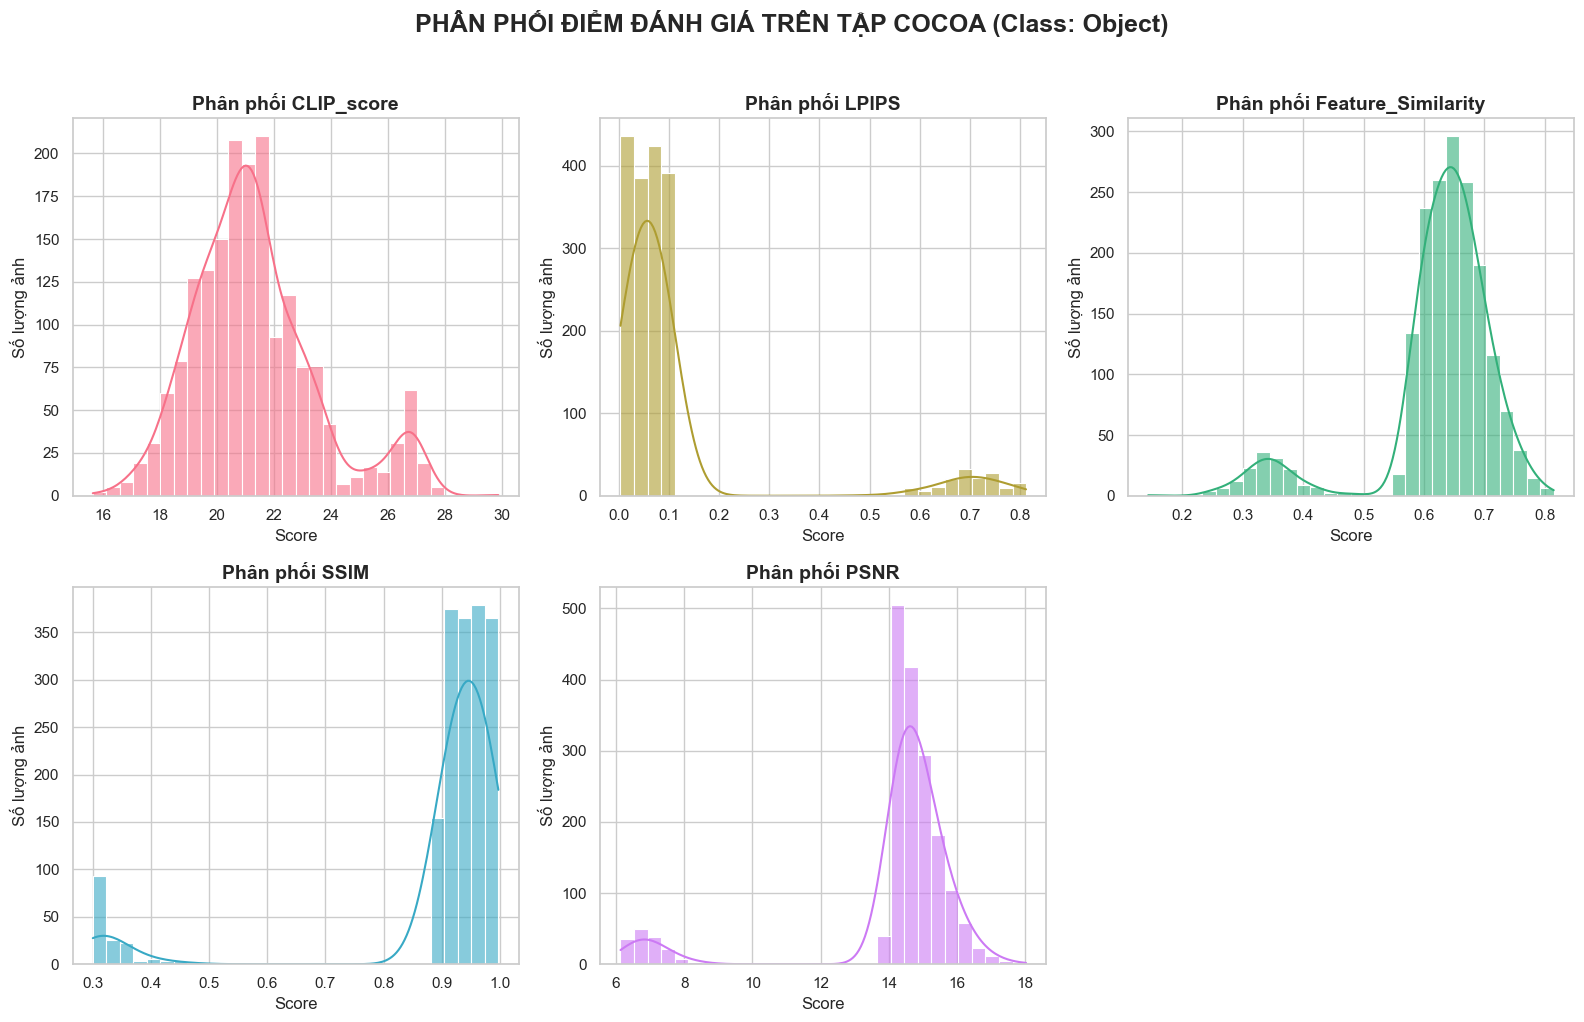

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Khai báo đường dẫn file COCOA
path_cocoa = '/Users/nguyenloan/Desktop/ProtoSAM+Amodal/results/cocoa_subset_results (1).csv'

# Set style
sns.set_theme(style="whitegrid")

def plot_cocoa_distributions(file_path):
    if not os.path.exists(file_path):
        print(f"❌ Không tìm thấy file: {file_path}")
        return
        
    df = pd.read_csv(file_path)
    
    # Các metric cần vẽ
    metrics = ['CLIP_score', 'LPIPS', 'Feature_Similarity', 'SSIM', 'PSNR']
    
    # Setup grid: 2 hàng, 3 cột
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    fig.suptitle("PHÂN PHỐI ĐIỂM ĐÁNH GIÁ TRÊN TẬP COCOA (Class: Object)", 
                 fontsize=18, fontweight='bold', y=1.02)
    
    # Dùng palette màu để các đồ thị khác nhau dễ nhìn
    colors = sns.color_palette("husl", len(metrics))
    
    for i, metric in enumerate(metrics):
        # Vẽ Histogram kèm đường KDE (đường cong mật độ)
        sns.histplot(data=df, x=metric, kde=True, ax=axes[i], 
                     color=colors[i], bins=30, alpha=0.6)
        
        # Trang trí đồ thị
        axes[i].set_title(f'Phân phối {metric}', fontsize=14, fontweight='bold')
        axes[i].set_ylabel('Số lượng ảnh')
        axes[i].set_xlabel('Score')
        
    # Xóa ô đồ thị trống cuối cùng (vì chỉ có 5 metrics)
    for j in range(len(metrics), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# Thực thi
plot_cocoa_distributions(path_cocoa)

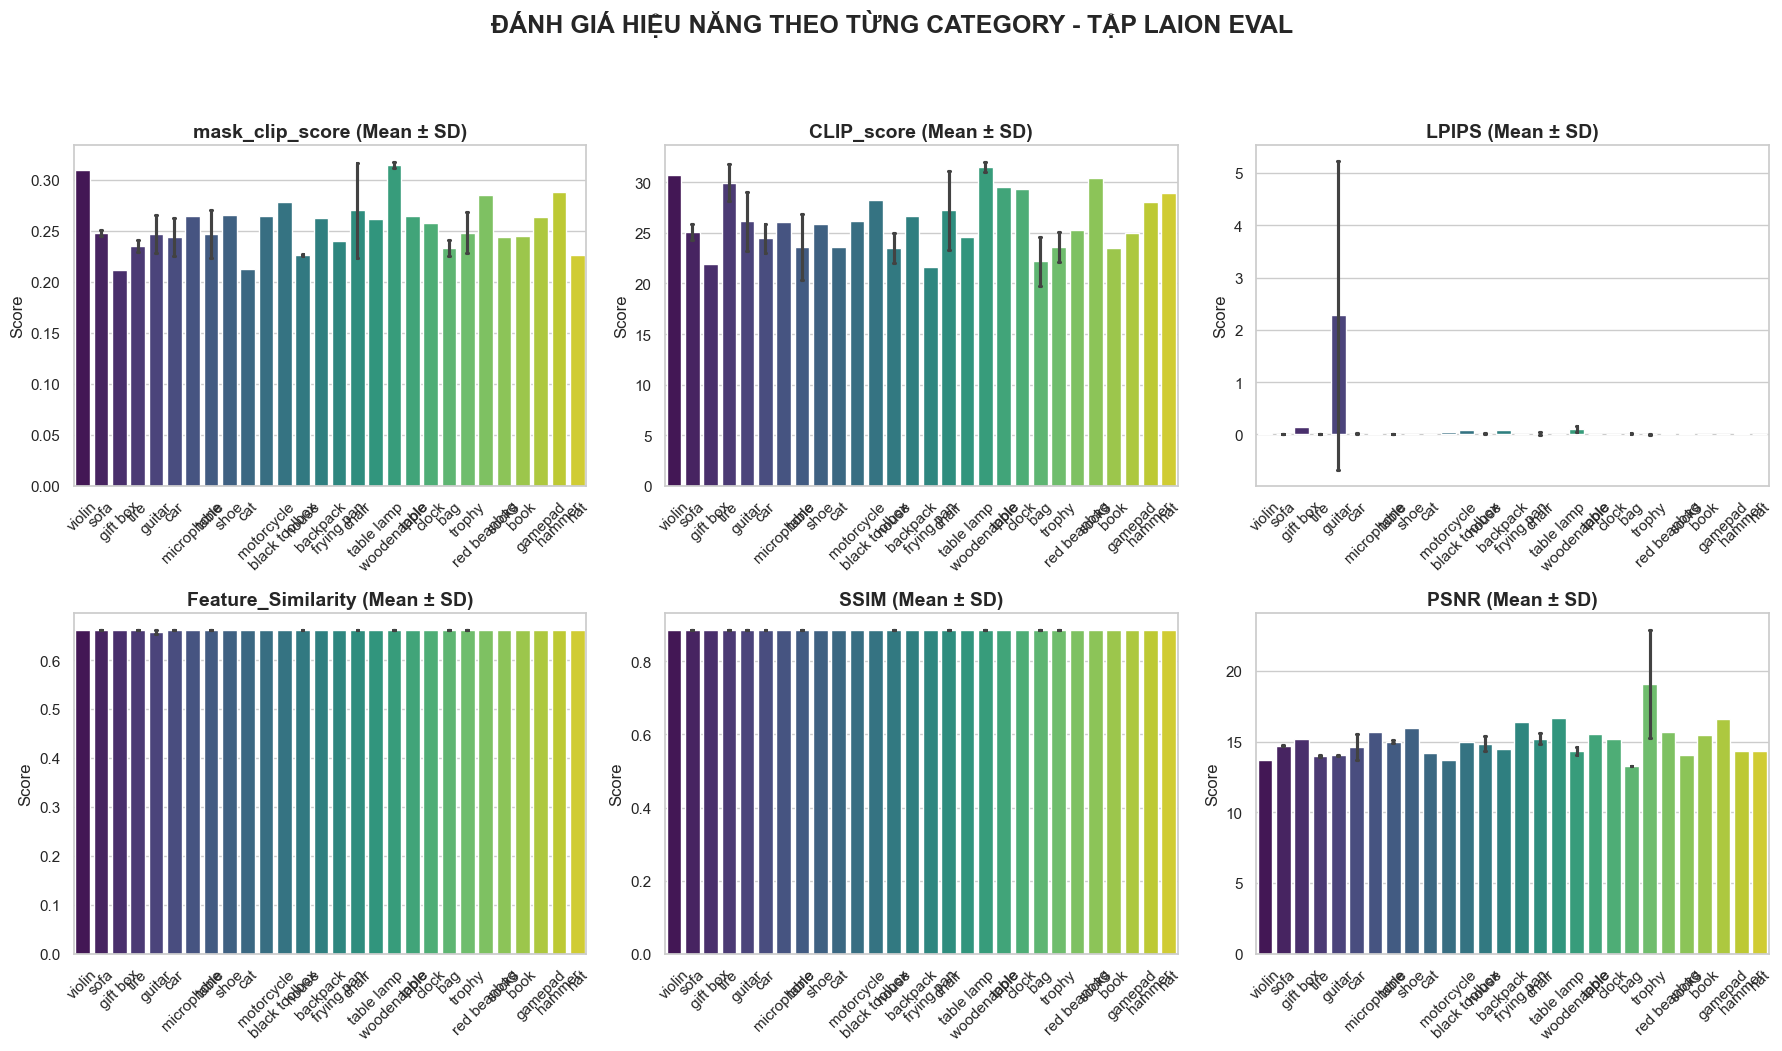

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Khai báo đường dẫn file LAION
path_laion = '/Users/nguyenloan/Desktop/ProtoSAM+Amodal/results/laion_eval_results.csv'

# Set style chuẩn báo cáo khoa học
sns.set_theme(style="whitegrid")

def plot_laion_barplots(file_path):
    if not os.path.exists(file_path):
        print(f"❌ Không tìm thấy file: {file_path}")
        return
        
    df = pd.read_csv(file_path)
    
    # 6 metrics của tập LAION
    metrics = ['mask_clip_score', 'CLIP_score', 'LPIPS', 'Feature_Similarity', 'SSIM', 'PSNR']
    
    # Setup grid: 2 hàng, 3 cột
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    fig.suptitle("ĐÁNH GIÁ HIỆU NĂNG THEO TỪNG CATEGORY - TẬP LAION EVAL", 
                 fontsize=18, fontweight='bold', y=1.05)
    
    for i, metric in enumerate(metrics):
        # ĐÃ FIX LỖI Ở ĐÂY: Thêm hue='category' và legend=False
        sns.barplot(data=df, x='category', y=metric, ax=axes[i], 
                    hue='category', palette='viridis', legend=False,
                    capsize=.1, errorbar='sd')
        
        # Format lại đồ thị
        axes[i].set_title(f'{metric} (Mean ± SD)', fontsize=14, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45) # Xoay tên category cho dễ đọc
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Score')
        
    plt.tight_layout()
    plt.show()

# 2. Thực thi
plot_laion_barplots(path_laion)